# Benchmark Python densification implementation with MATLAB results

In [1]:
import xarray as xr
import numpy as np
import scipy
from matplotlib import pyplot as plt

from depsi.densification import densification

In [ ]:
# # Make a dask cluster for compute large number of points
# from dask.distributed import Client, LocalCluster
# cluster = LocalCluster()
# client = Client(cluster)
# client

In [3]:
# Matlab files
file_mat_output_full = "../../data/marken_tsx_testdata_densification/marken_tsx_densification_testdata_full_v3/marken_tsx_densification_testdata_output_v3.mat"
data_output_full = scipy.io.loadmat(file_mat_output_full)

# Inspect keys in matlab results
data_output_full.keys()

dict_keys(['__header__', '__version__', '__globals__', 'B1', 'B1Qy2', 'Bdop', 'Btemp', 'N', 'Namp_disp_bins', 'Nbuffers', 'Ncon', 'Ncv', 'Ndens_iterations', 'Nest', 'Ngrid', 'Nifgs', 'Nlines', 'Nmodels', 'Npar', 'Npar_max', 'Nparts', 'Npixels', 'Nps', 'Nps_defo', 'Nps_grid', 'Nps_index', 'Npsc', 'Npsc_selections', 'Npsp', 'Npsp_buffer', 'Npsp_grid', 'Npsp_rem_buffer', 'Nref', 'Nslc', 'Qahat', 'Qy', 'Qy_new', 'R', 'Rinv', 'Tb', 'althyp_index', 'altimg', 'amplitude_calibration', 'ans', 'atmo_range', 'az_spacing', 'breakpoint', 'breakpoint2', 'calfactors', 'center_az', 'center_r', 'comment_line', 'covar_index', 'covar_reshape', 'crop', 'cropFinal', 'cropIn', 'crop_in', 'dates', 'defo_index', 'defo_method', 'defo_model_flag', 'defo_range', 'demFile', 'dens_check', 'dens_method', 'densification_flag', 'detail_plots', 'detrend_flag', 'detrend_method', 'distance', 'do_aposteriori_sidelobe_mask', 'do_apriori_sidelobe_mask', 'dummy', 'ehat', 'ehat2', 'ens_coh_threshold', 'epoch', 'excludeDate',

In [4]:
data_output_full['ref_index']

array([[49]], dtype=uint8)

In [5]:
data_output_full['psc_phase_final']

array([[ 0.09260579, -2.20341588, -0.61930054, ...,  0.72821423,
         0.3224718 , -0.21493905],
       [ 0.09260579, -2.20341588, -0.61930054, ...,  0.72821423,
         0.3224718 , -0.21493905],
       [ 0.09260579, -2.20341588, -0.61930054, ...,  0.72821423,
         0.3224718 , -0.21493905],
       ...,
       [ 0.09260579, -2.20341588, -0.61930054, ...,  0.72821423,
         0.3224718 , -0.21493905],
       [ 0.09260579, -2.20341588, -0.61930054, ...,  0.72821423,
         0.3224718 , -0.21493905],
       [ 0.09260579, -2.20341588, -0.61930054, ...,  0.72821423,
         0.3224718 , -0.21493905]], shape=(18203, 359))

In [6]:
# Build network points dataset from matlab inputs
azimuth_coords = data_output_full["psc_az_new"]
range_coords = data_output_full["psc_r_new"]
ambiguities = data_output_full["psc_acheck_new"] # ambiguities w.r.t the ref point
sd_phase = data_output_full["psc_phase_new"]
h2ph = data_output_full["psc_h2ph_new"]
time = data_output_full["Btemp"].flatten()

stm_network_pnt = xr.Dataset(
    coords={
        "azimuth": (("space",), azimuth_coords.flatten()),
        "range": (("space",), range_coords.flatten()),
        "space": ("space", np.arange(azimuth_coords.size)),
        "time": (("time",), time),
    },
    data_vars={
        "ambiguities": (("space", "time"), ambiguities),
        "sd_phase": (("space", "time"), sd_phase),
        "h2ph_values": (("space", "time"), h2ph),
        "Btemp": (("time",), time),
    },
)

stm_network_pnt

<xarray.Dataset> Size: 2MB
Dimensions:      (space: 218, time: 359)
Coordinates:
  * space        (space) int64 2kB 0 1 2 3 4 5 6 ... 211 212 213 214 215 216 217
  * time         (time) float64 3kB -8.167 -8.137 -8.107 ... 5.877 5.907 5.937
    azimuth      (space) uint16 436B 471 472 478 486 513 ... 1954 2013 2023 2051
    range        (space) uint16 436B 1229 1180 1111 1027 ... 573 294 384 460
Data variables:
    ambiguities  (space, time) float64 626kB -0.0 0.0 0.0 0.0 ... -0.0 0.0 0.0
    sd_phase     (space, time) float64 626kB -0.8485 -1.198 ... -0.1879 0.2219
    h2ph_values  (space, time) float64 626kB 0.001351 4.578e-05 ... -0.0002178
    Btemp        (time) float64 3kB -8.167 -8.137 -8.107 ... 5.877 5.907 5.937

In [7]:
# build densification stm
azimuth_coords = data_output_full['ps_az_final']
range_coords = data_output_full["ps_r_final"]
sd_phase = data_output_full["psp_phase_final"]
h2ph = data_output_full["ps_h2ph_final"]
ambiguities_valiate = data_output_full["psp_acheck_final"] # matlab ambiguity densification solutions w.r.t the network point
phase_unw_final = data_output_full["ps_phase_unw_final"]
time = data_output_full["Btemp"].flatten()

stm_densification = xr.Dataset(
    coords={
        "azimuth": ("space", azimuth_coords.flatten()),
        "range": ("space", range_coords.flatten()),
        "space": ("space", np.arange(azimuth_coords.size)),
        "time": ("time", time),
    },
    data_vars={
        "sd_phase": (("space", "time"), sd_phase),
        "h2ph_values": (("space", "time"), h2ph),
        "ambiguities_valiate": (("space", "time"), ambiguities_valiate),
        "phase_unw_final": (("space", "time"), phase_unw_final),
        "Btemp": (("time",), time),
    },
)

# stm_densification = stm_densification.isel(space=range(0, 10000, 5))

stm_densification

<xarray.Dataset> Size: 209MB
Dimensions:              (space: 18203, time: 359)
Coordinates:
  * space                (space) int64 146kB 0 1 2 3 ... 18199 18200 18201 18202
  * time                 (time) float64 3kB -8.167 -8.137 -8.107 ... 5.907 5.937
    azimuth              (space) uint16 36kB 471 472 478 486 ... 2060 2060 2061
    range                (space) uint16 36kB 1229 1180 1111 1027 ... 578 579 578
Data variables:
    sd_phase             (space, time) float64 52MB -0.8485 -1.198 ... -0.6591
    h2ph_values          (space, time) float64 52MB 0.001351 ... -0.0002177
    ambiguities_valiate  (space, time) float64 52MB 0.0 0.0 0.0 ... 0.0 -0.0 0.0
    phase_unw_final      (space, time) float64 52MB -0.9411 1.005 ... -0.4441
    Btemp                (time) float64 3kB -8.167 -8.137 -8.107 ... 5.907 5.937

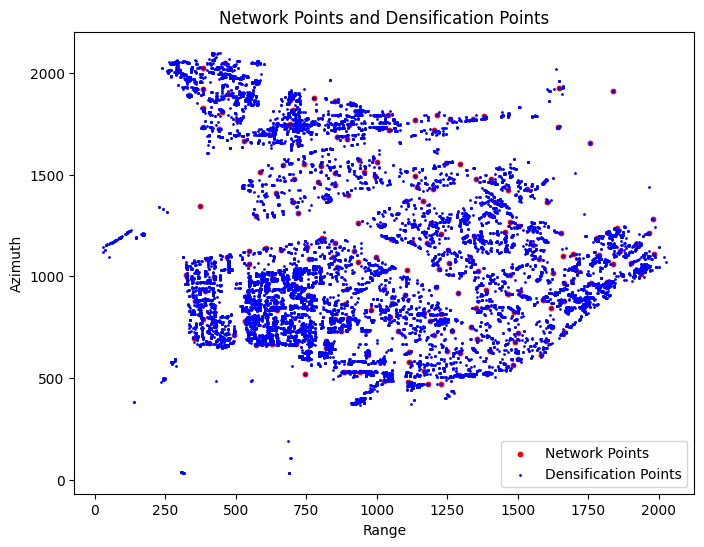

In [8]:
# Plot network points with densification points
plt.figure(figsize=(8, 6))
plt.scatter(
    stm_network_pnt["range"],
    stm_network_pnt["azimuth"],
    c="red",
    label="Network Points",
    s=10,
)
plt.scatter(
    stm_densification["range"],
    stm_densification["azimuth"],
    c="blue",
    label="Densification Points",
    s=1,
)
plt.xlabel("Range")
plt.ylabel("Azimuth")
plt.title("Network Points and Densification Points")
plt.legend()

In [ ]:
# WAVELENGTH = 0.031066581904661 # TSX wavelength in meters
# stm_densified = densification(
#     stm_densification,
#     stm_network_pnt,
#     wavelength=WAVELENGTH,
#     n_connections=1,
#     key_xcoord="azimuth",
#     key_ycoord="range",
#     key_btemp="Btemp",
#     key_h2ph="h2ph_values",
#     key_sdphase="sd_phase",
#     std_height=30.0,
#     std_vel=0.02,
# ) # This takes ~ 40 mins

# stm_densified.to_zarr('stm_densified.zarr')

# load results from zarr
stm_densified = xr.open_zarr('stm_densified.zarr')
stm_densified = stm_densified.compute()

In [10]:
stm_densified

<xarray.Dataset> Size: 314MB
Dimensions:              (space: 18203, time: 359)
Coordinates:
  * space                (space) int64 146kB 0 1 2 3 ... 18199 18200 18201 18202
  * time                 (time) float64 3kB -8.167 -8.137 -8.107 ... 5.907 5.937
    azimuth              (space) uint16 36kB 471 472 478 486 ... 2060 2060 2061
    pnt_uid              (space) uint64 146kB 2594277962079200655 ... 2964232...
    range                (space) uint16 36kB 1229 1180 1111 1027 ... 578 579 578
Data variables:
    ambiguities          (space, time) float64 52MB -0.0 0.0 0.0 ... 0.0 0.0 0.0
    ambiguities_valiate  (space, time) float64 52MB nan nan nan ... 0.0 -0.0 0.0
    Btemp                (space, time) float64 52MB -8.167 -8.137 ... 5.937
    h2ph_values          (space, time) float64 52MB 0.001351 ... -0.0002177
    phase_unw_final      (space, time) float64 52MB nan nan ... -1.02 -0.4441
    sd_phase             (space, time) float64 52MB -0.8485 -1.198 ... -0.6591

## Perform densification

In [11]:
# Ambiguity check
n_skip_network_pnts = stm_network_pnt["space"].size

# Python solution
ambigs_python = stm_densified["ambiguities"].isel(space=range(n_skip_network_pnts, stm_densified['ambiguities'].sizes['space']))


# Ambuity Matlab
ambigs_matlab = stm_densified["ambiguities_valiate"].isel(space=range(n_skip_network_pnts, stm_densified['ambiguities'].sizes['space']))

amb_diff = ambigs_python - ambigs_matlab # ambiguity differences

In [12]:
amb_diff

<xarray.DataArray (space: 17985, time: 359)> Size: 52MB
array([[ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       ...,
       [-0.,  0.,  0., ...,  0.,  0.,  0.],
       [-0.,  0.,  0., ...,  0.,  0.,  0.],
       [-0.,  0.,  0., ...,  0.,  0.,  0.]], shape=(17985, 359))
Coordinates:
  * space    (space) int64 144kB 218 219 220 221 222 ... 18199 18200 18201 18202
  * time     (time) float64 3kB -8.167 -8.137 -8.107 ... 5.877 5.907 5.937
    azimuth  (space) uint16 36kB 35 35 35 35 36 36 ... 2060 2060 2060 2060 2061
    pnt_uid  (space) uint64 144kB 17421777164327052254 ... 2964232480167617027
    range    (space) uint16 36kB 309 314 315 316 307 308 ... 575 577 578 579 578

In [13]:
# fig, axes = plt.subplots(1, 3, figsize=(15, 10))
# for ax, data, title in zip(axes, [ambigs_python, ambigs_matlab, amb_diff],
#                            ["Ambiguities (Python)", "Ambiguities (Matlab)", "Ambiguity Differences"]):
#     im = ax.imshow(data.values, aspect=2, cmap='viridis', vmin=-2, vmax=2)
#     ax.set_title(title)
#     # set aspect ratio
#     ax.set_aspect(0.05)
# # tighten layout
# fig.tight_layout()
# plt.colorbar(im, ax=axes[2])

In [14]:
# Unwrapped phase check
n_skip_network_pnts = stm_network_pnt["space"].size

# Get reference point phase
ref_index = data_output_full['ref_index']
ref_phase = data_output_full['psc_phase_final'][ref_index][0]
# Python solution
ambigs_python = stm_densified["ambiguities"].isel(space=range(n_skip_network_pnts, stm_densified['ambiguities'].sizes['space']))
sd_phase_python = stm_densified["sd_phase"].isel(space=range(n_skip_network_pnts, stm_densified['sd_phase'].sizes['space']))
phase_unw_python = sd_phase_python + 2 * np.pi * ambigs_python - np.tile(ref_phase, (sd_phase_python.sizes['space'],1)) # subtract ref point phase


# Ambuity Matlab
# ambigs_matlab = stm_densified["ambiguities_valiate"].isel(space=range(n_skip_network_pnts, stm_densified['ambiguities'].sizes['space']))
phase_unw_matlab = stm_densified["phase_unw_final"].isel(space=range(n_skip_network_pnts, stm_densified['phase_unw_final'].sizes['space']))

# amb_diff = ambigs_python - ambigs_matlab # ambiguity differences
phase_diff = phase_unw_python - phase_unw_matlab # phase differences


In [15]:
phase_diff

<xarray.DataArray (space: 17985, time: 359)> Size: 52MB
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(17985, 359))
Coordinates:
  * space    (space) int64 144kB 218 219 220 221 222 ... 18199 18200 18201 18202
  * time     (time) float64 3kB -8.167 -8.137 -8.107 ... 5.877 5.907 5.937
    azimuth  (space) uint16 36kB 35 35 35 35 36 36 ... 2060 2060 2060 2060 2061
    pnt_uid  (space) uint64 144kB 17421777164327052254 ... 2964232480167617027
    range    (space) uint16 36kB 309 314 315 316 307 308 ... 575 577 578 579 578

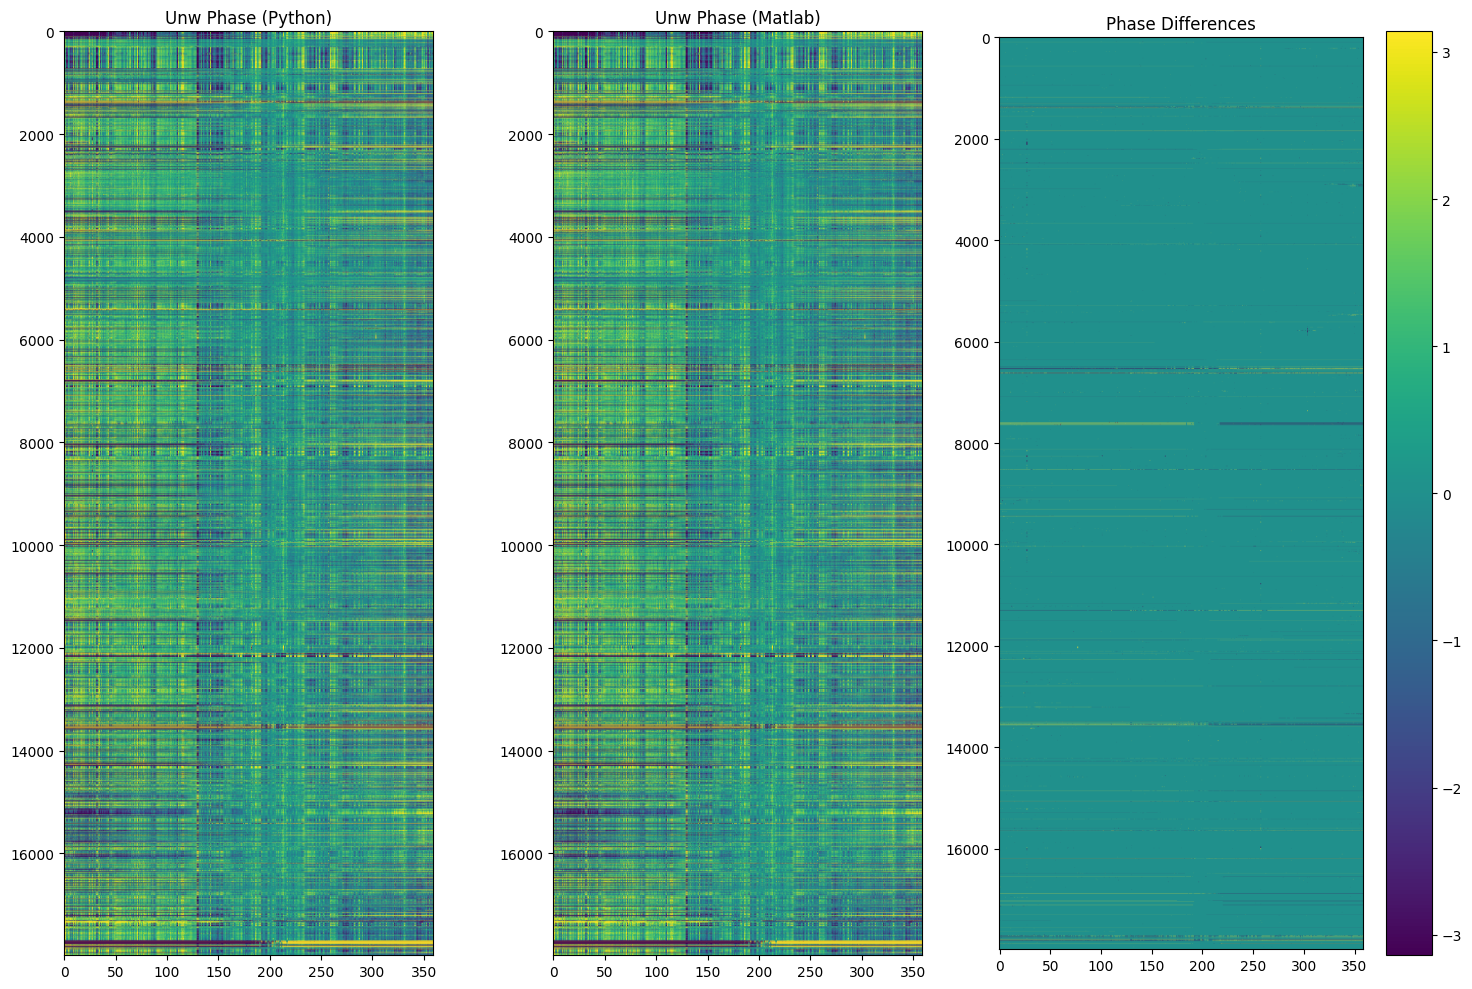

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 10))

for ax, data, title in zip(axes, [phase_unw_python, phase_unw_python, phase_diff],
                           ["Unw Phase (Python)", "Unw Phase (Matlab)", "Phase Differences"]):
    im = ax.imshow(data.values, aspect=2, cmap='viridis', vmin=-3.14, vmax=3.14)
    ax.set_title(title)
    # set aspect ratio
    ax.set_aspect(0.05)
# tighten layout
fig.tight_layout()
plt.colorbar(im, ax=axes[2])

Text(0, 0.5, 'Sum of Absolute Phase Differences')

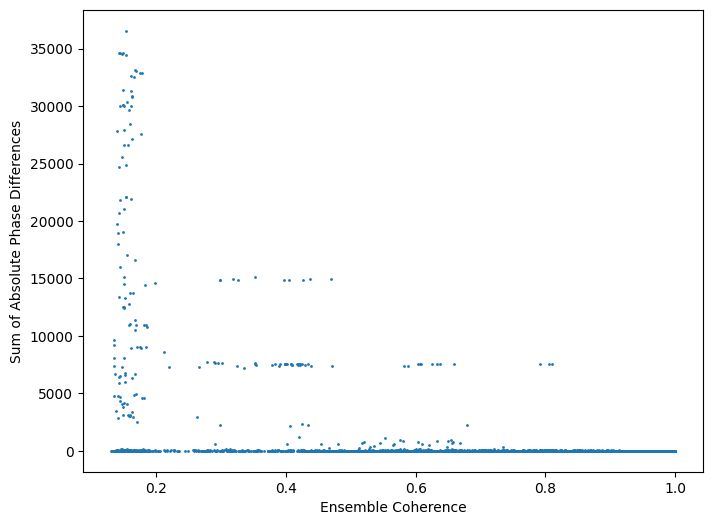

In [17]:
# Study differences vs enscoh
ens_coh = data_output_full['ps_ens_coh_final'][n_skip_network_pnts:] # 
phase_diff_sum = np.nansum(np.abs(phase_diff.values), axis=1)

plt.figure(figsize=(8,6))
plt.plot(ens_coh, phase_diff_sum, '.', markersize=2)
plt.xlabel('Ensemble Coherence')
plt.ylabel('Sum of Absolute Phase Differences')

In [24]:
# Get the percentage of points with phase difference with 0
percent_zero_diff = np.sum(phase_diff_sum == 0) / phase_diff_sum.shape[0] * 100
print(f'Percentage of points with zero phase difference: {percent_zero_diff:.2f}%')

Percentage of points with zero phase difference: 89.77%
